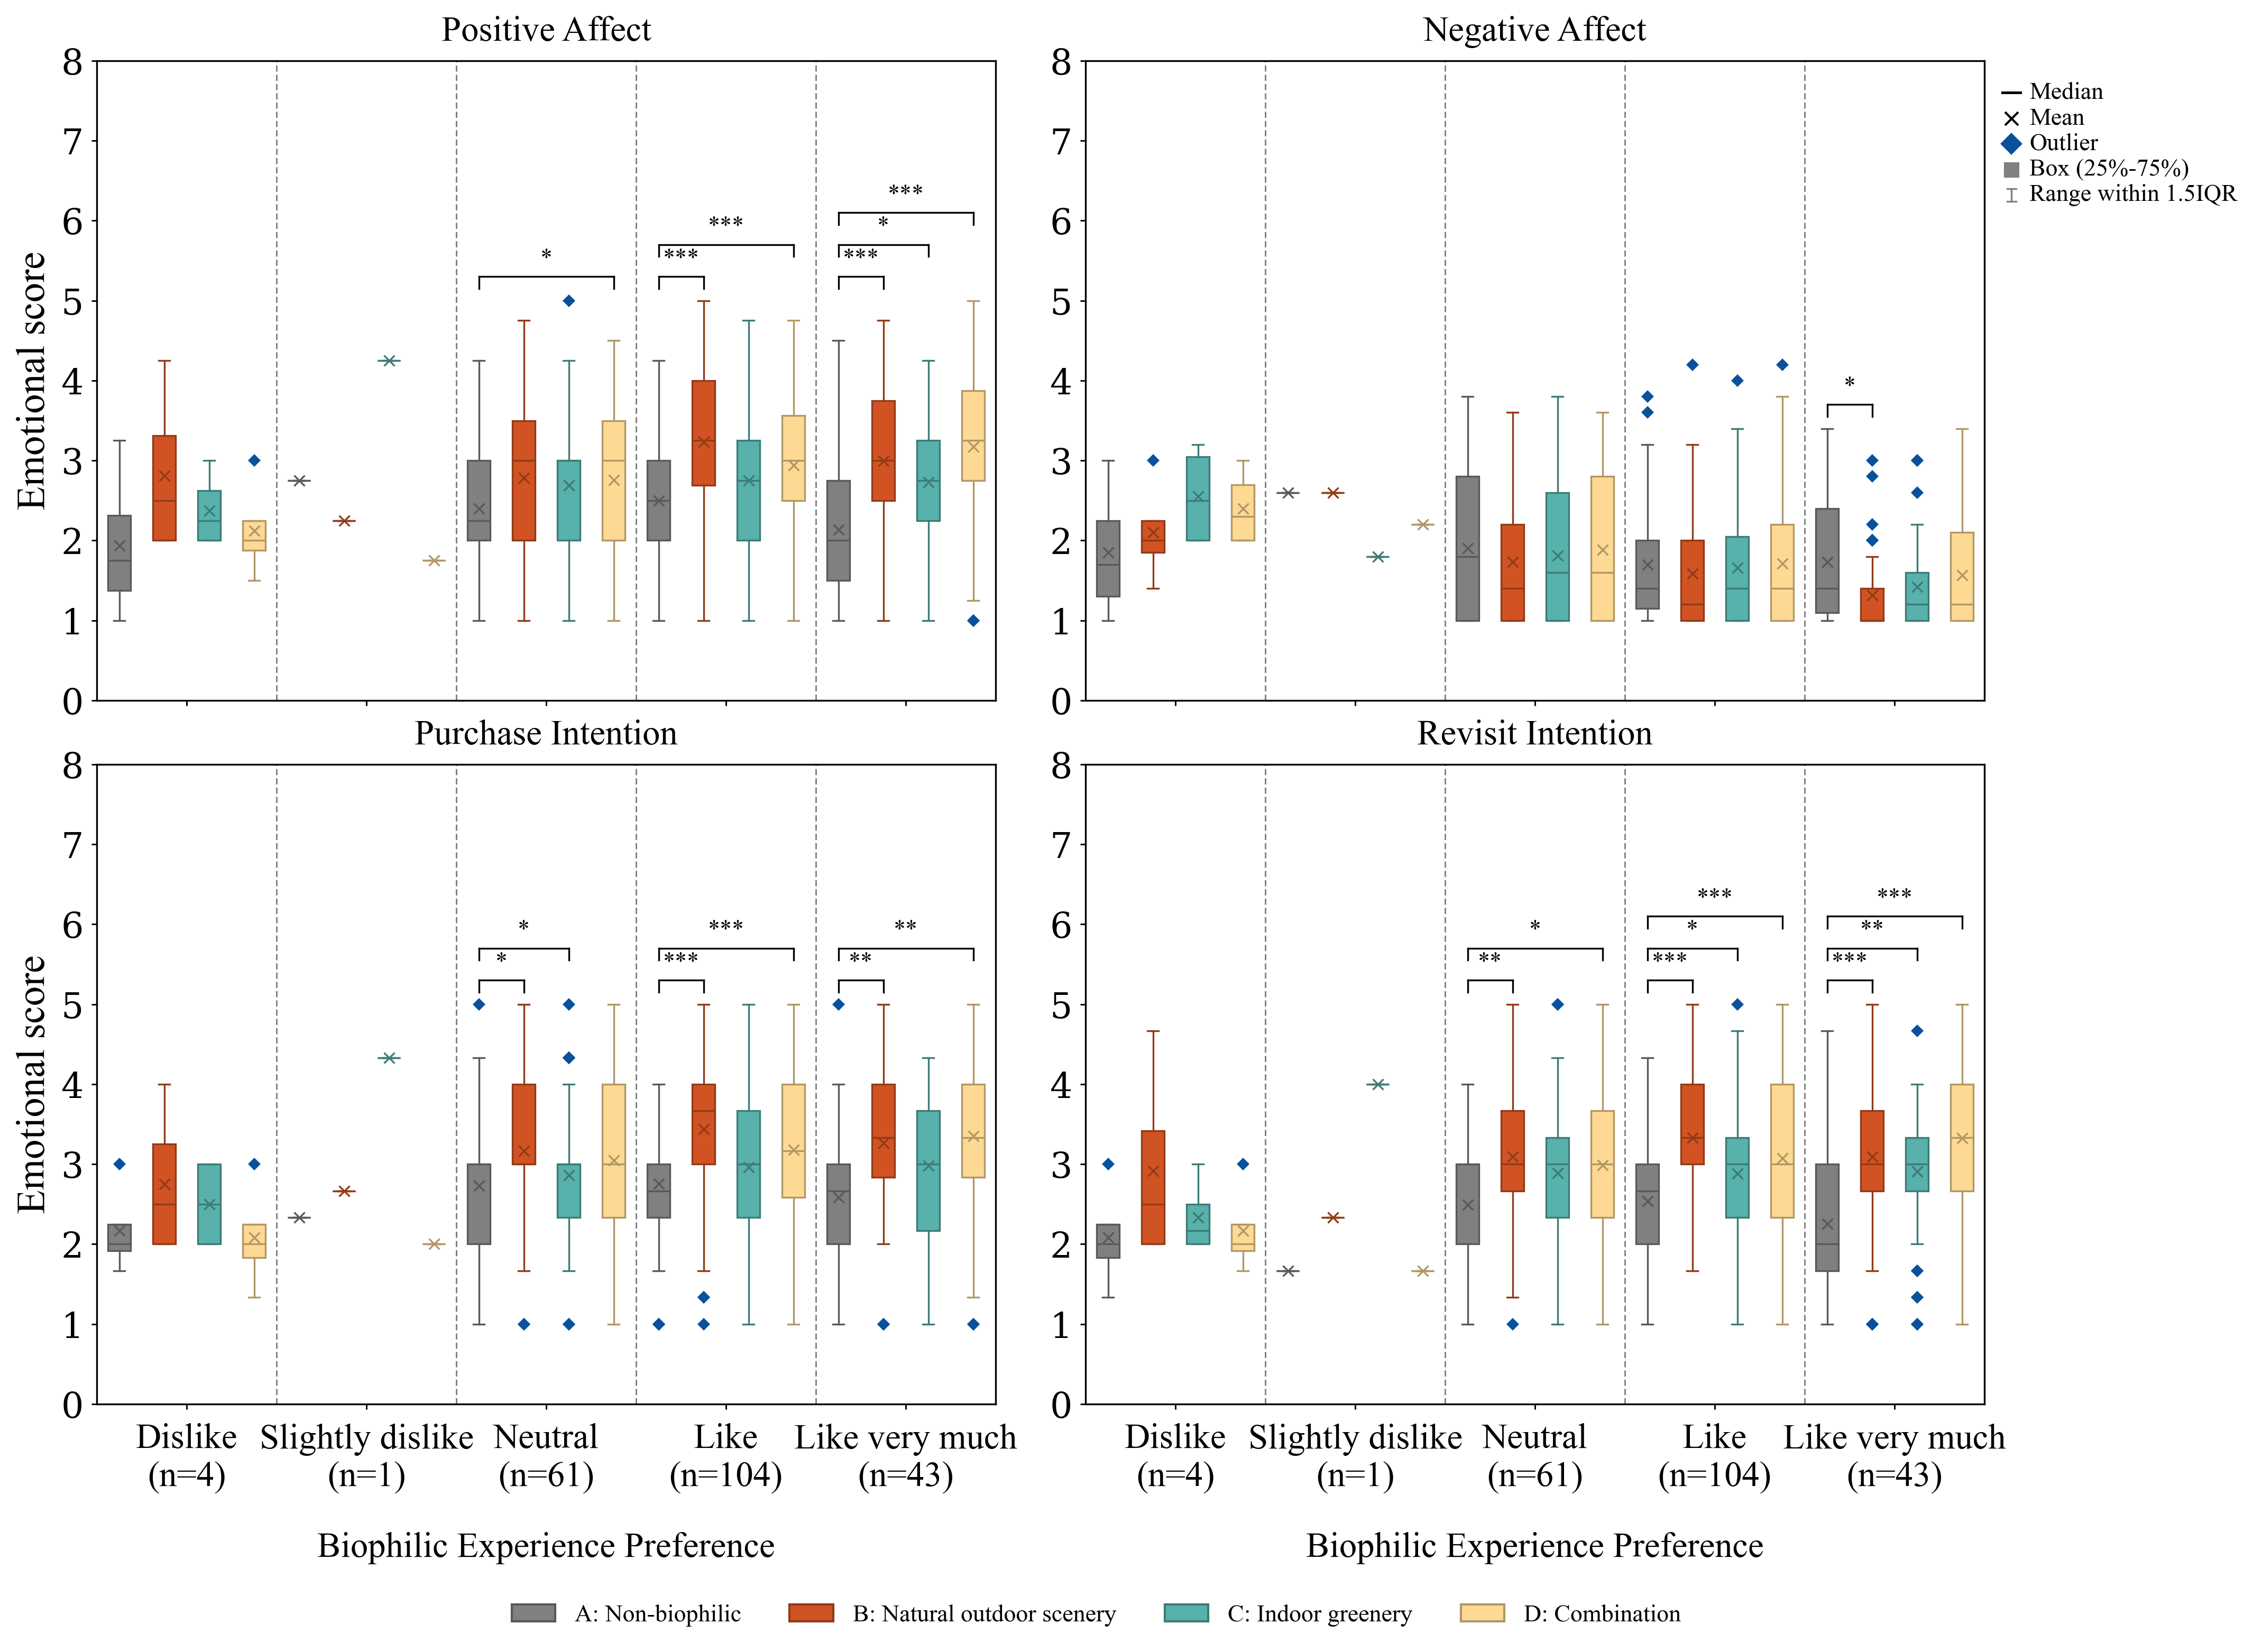

📊 亲自然体验偏好分析 - 统计结果报告（仅A vs B/C/D）

1. 描述性统计（均值±标准差，样本量n）
------------------------------------------------------------

【Positive Affect】
  Dislike (n=4)（小样本组，仅描述）:
    A: Non-biophilic: 均值±标准差=1.94±0.97, n=4
    B: Natural outdoor scenery: 均值±标准差=2.81±1.07, n=4
    C: Indoor greenery: 均值±标准差=2.38±0.48, n=4
    D: Combination: 均值±标准差=2.12±0.63, n=4
  Slightly dislike (n=1)（小样本组，仅描述）:
    A: Non-biophilic: 均值=2.75, n=1
    B: Natural outdoor scenery: 均值=2.25, n=1
    C: Indoor greenery: 均值=4.25, n=1
    D: Combination: 均值=1.75, n=1
  Neutral (n=61):
    A: Non-biophilic: 均值±标准差=2.4±0.76, n=61
    B: Natural outdoor scenery: 均值±标准差=2.78±0.87, n=61
    C: Indoor greenery: 均值±标准差=2.69±0.88, n=61
    D: Combination: 均值±标准差=2.76±0.9, n=61
  Like (n=104):
    A: Non-biophilic: 均值±标准差=2.5±0.67, n=104
    B: Natural outdoor scenery: 均值±标准差=3.23±0.93, n=104
    C: Indoor greenery: 均值±标准差=2.75±0.85, n=104
    D: Combination: 均值±标准差=2.94±0.9, n=104
  Like very much (n=43):
    A: Non-biophilic: 均值±

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
import itertools
import scikit_posthocs as sp

# --------------------------
# 1. 全局配置（保留原有字体配置，不修改）
# --------------------------
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8  # 【全局字体大小控制】整个图表的默认字体大小
plt.rcParams['axes.linewidth'] = 0.8
# 刻度线设为外侧
plt.rcParams['xtick.direction'] = 'out'   
plt.rcParams['ytick.direction'] = 'out'   
plt.rcParams['xtick.major.size'] = 2.5   
plt.rcParams['ytick.major.size'] = 2.5
plt.rcParams['xtick.major.width'] = 0.7  
plt.rcParams['ytick.major.width'] = 0.7
plt.rcParams['font.family'] = 'serif'

# --------------------------
# 标签配置（核心修改：样本量添加括号）
# --------------------------
# 拆分标签为文字和样本量两部分，样本量直接带括号
prefer_groups = [
    ('Dislike', '(n=4)'),
    ('Slightly dislike', '(n=1)'),
    ('Neutral', '(n=61)'),
    ('Like', '(n=104)'),
    ('Like very much', '(n=43)')
]
# 小样本组判断（用第一部分文字匹配）
small_sample_groups = ['Dislike', 'Slightly dislike']  
# 核心修改：仅保留A与B/C/D的对比
key_comparisons = [
    ('A: Non-biophilic', 'B: Natural outdoor scenery'),
    ('A: Non-biophilic', 'C: Indoor greenery'),
    ('A: Non-biophilic', 'D: Combination')
]  
# 消极情绪保留所有A的对比
negative_affect_key_compare = key_comparisons  

environments = [
    'A: Non-biophilic',
    'B: Natural outdoor scenery',
    'C: Indoor greenery',
    'D: Combination'
]
dimensions = [
    'Positive Affect',
    'Negative Affect',
    'Purchase Intention',
    'Revisit Intention'
]

env_colors = ['#808080', '#D15323', '#58B1AB', '#FED993']  

# 颜色加深函数
def darken_color(hex_color, factor=0.7):
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    
    r = max(0, int(r * factor))
    g = max(0, int(g * factor))
    b = max(0, int(b * factor))
    
    return f'#{r:02x}{g:02x}{b:02x}'

env_colors_dark = [darken_color(color) for color in env_colors]
dashed_line = (0, (4, 2))
sig_mapping = {
    (0, 0.001): '***',
    (0.001, 0.01): '**',
    (0.01, 0.05): '*',
    (0.05, 1): ''
}

# --------------------------
#统计结果存储字典
# --------------------------
statistical_results = {
    'descriptive_stats': {},  # 描述性统计（均值/标准差/样本量）
    'kruskal_wallis': {},     # Kruskal-Wallis检验结果
    'dunn_test': {}           # Dunn事后检验结果
}

# --------------------------
# 调整行间距 + 缩小符号文字水平距离
# --------------------------
def add_boxplot_annotation(
    ax,
    x_pos=1.03,          
    y_pos=0.98,          
    font_family='Times New Roman',  
    font_size=7,         # 【图注字体大小控制】可修改数值（如8、9）
    font_color='#000000' 
):
    """
    图注：包含Median/Mean/Outlier/Box/Whiskers，须线符号为工字形
    """
    # 1. 逐行配置：删除分组虚线，仅保留核心箱体图元素
    line_y = [0, -0.04, -0.08, -0.12, -0.16]  # 行间距0.04
    texts = [
        'Median', 
        'Mean', 
        'Outlier', 
        'Box (25%-75%)', 
        'Range within 1.5IQR'  # 须线说明文字
    ]
    
    # 绘制每行文字
    for i, txt in enumerate(texts):
        ax.text(
            x_pos + 0.02,  # 文字与符号的水平距离
            y_pos + line_y[i],
            txt,
            ha='left', va='center',  # 垂直居中对齐
            fontsize=font_size,      # 【字体大小控制】图注文字大小
            fontfamily=font_family,
            color=font_color,
            transform=ax.transAxes,
            clip_on=False,
            fontweight='normal'      # 【加粗控制】normal=不加粗, bold=加粗
        )
    
    # 2. 绘制所有符号（须线为工字形）
    # Median 横线
    ax.plot(
        [x_pos - 0.01, x_pos + 0.01],  
        [y_pos + line_y[0], y_pos + line_y[0]],  
        color='#000000', linewidth=1.2,
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )
    # Mean 叉号
    ax.plot(
        [x_pos], 
        [y_pos + line_y[1]],  
        marker='x', markersize=6, color='#000000',
        markeredgecolor='#000000', markerfacecolor='#000000',
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )
    # Outlier 菱形
    ax.plot(
        [x_pos], 
        [y_pos + line_y[2]],
        marker='D', markersize=6, color='#09519D',
        markeredgecolor='#09519D', markerfacecolor='#09519D',
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )
    # Box 正方形
    ax.plot(
        [x_pos], 
        [y_pos + line_y[3]],
        marker='s', markersize=6, color='#808080',
        markeredgecolor='#808080', markerfacecolor='#808080',
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )
    # 工字形须线符号
    # 垂直竖线（中间）
    ax.plot(
        [x_pos, x_pos],  
        [y_pos + line_y[4] - 0.01, y_pos + line_y[4] + 0.01],  # 上下各0.01，完全居中
        color='#808080', linewidth=0.8,
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )
    # 下短横
    ax.plot(
        [x_pos - 0.005, x_pos + 0.005],  
        [y_pos + line_y[4] - 0.01, y_pos + line_y[4] - 0.01],  
        color='#808080', linewidth=0.8,
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )
    # 上短横
    ax.plot(
        [x_pos - 0.005, x_pos + 0.005],  
        [y_pos + line_y[4] + 0.01, y_pos + line_y[4] + 0.01],  
        color='#808080', linewidth=0.8,
        transform=ax.transAxes, 
        clip_on=False,
        zorder=10
    )

# --------------------------
# 2. 读取Excel数据的适配函数
# --------------------------
def load_real_excel_data(excel_path, sheet_name=0):
    df = pd.read_excel(excel_path, sheet_name=0)
    required_columns = ['维度', '偏好分组', '环境', '得分']
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"Excel工作表必须包含列：{required_columns}")
    
    # 调整映射关系，匹配带括号的样本量
    pg_mapping = {
        '很不喜欢(n=4)': ('Dislike', '(n=4)'),
        '不喜欢(n=1)': ('Slightly dislike', '(n=1)'),
        '一般(n=61)': ('Neutral', '(n=61)'),
        '喜欢(n=104)': ('Like', '(n=104)'),
        '非常喜欢(n=43)': ('Like very much', '(n=43)')
    }
    df['偏好分组'] = df['偏好分组'].map(pg_mapping)
    
    df = df[
        (df['维度'].isin(dimensions)) &
        (df['偏好分组'].isin(prefer_groups)) &
        (df['环境'].isin(environments)) &
        (pd.notna(df['得分']))
    ]
    
    # 初始化描述性统计存储
    statistical_results['descriptive_stats'] = {dim: {pg: {} for pg in prefer_groups} for dim in dimensions}
    
    data = {dim: {pg: [] for pg in prefer_groups} for dim in dimensions}
    for dim in dimensions:
        for pg in prefer_groups:
            subset = df[(df['维度'] == dim) & (df['偏好分组'] == pg)]
            env_stats = []
            for env in environments:
                env_scores = subset[subset['环境'] == env]['得分'].values
                n = len(env_scores)
                if n == 0:
                    mean = np.nan
                    std = np.nan
                    env_stats.append((mean, std, n))
                elif n == 1:
                    mean = np.mean(env_scores)
                    std = np.nan
                    env_stats.append((mean, std, n))
                else:
                    mean = np.mean(env_scores)
                    std = np.std(env_scores, ddof=1)
                    env_stats.append((mean, std, n))
                # 存储描述性统计
                statistical_results['descriptive_stats'][dim][pg][env] = {
                    'mean': round(mean, 2),
                    'std': round(std, 2) if not np.isnan(std) else np.nan,
                    'n': n
                }
            data[dim][pg] = env_stats
    return data

def get_real_sample_data_from_excel(excel_path, sheet_name=0):
    df = pd.read_excel(excel_path, sheet_name=0)
    required_columns = ['维度', '偏好分组', '环境', '得分']
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"Excel工作表必须包含列：{required_columns}")
    
    # 调整映射关系，匹配带括号的样本量
    pg_mapping = {
        '很不喜欢(n=4)': ('Dislike', '(n=4)'),
        '不喜欢(n=1)': ('Slightly dislike', '(n=1)'),
        '一般(n=61)': ('Neutral', '(n=61)'),
        '喜欢(n=104)': ('Like', '(n=104)'),
        '非常喜欢(n=43)': ('Like very much', '(n=43)')
    }
    df['偏好分组'] = df['偏好分组'].map(pg_mapping)
    
    sample_data = {dim: {pg: {env: [] for env in environments} for pg in prefer_groups} for dim in dimensions}
    for _, row in df.iterrows():
        dim = row['维度']
        pg = row['偏好分组']
        env = row['环境']
        score = row['得分']
        if dim in dimensions and pg in prefer_groups and env in environments and pd.notna(score):
            sample_data[dim][pg][env].append(score)
    return sample_data

# --------------------------
# 3. 显著性计算函数（核心修改：仅处理A与B/C/D的对比）
# --------------------------
def calculate_significance(dim, prefer_group, data_dict, excel_path, sheet_name=0):
    # 1. 小样本组直接返回空，不做显著性标注（匹配拆分后的第一部分文字）
    if prefer_group[0] in small_sample_groups:
        return []
    
    # 初始化该维度-偏好组的统计存储
    if dim not in statistical_results['kruskal_wallis']:
        statistical_results['kruskal_wallis'][dim] = {}
        statistical_results['dunn_test'][dim] = {}
    statistical_results['kruskal_wallis'][dim][prefer_group] = {}
    statistical_results['dunn_test'][dim][prefer_group] = {}
    
    real_samples = get_real_sample_data_from_excel(excel_path, sheet_name)
    env_scores_dict = {}
    valid_envs = []
    for env in environments:
        scores = real_samples[dim][prefer_group][env]
        if len(scores) > 1:
            env_scores_dict[env] = scores
            valid_envs.append(env)
    
    if len(valid_envs) < 2:
        return []
    
    # 2. Kruskal-Wallis整体检验
    kw_data = [env_scores_dict[env] for env in valid_envs]
    try:
        h_stat, p_kw = stats.kruskal(*kw_data)
        # 存储Kruskal-Wallis结果
        statistical_results['kruskal_wallis'][dim][prefer_group] = {
            'H_stat': round(h_stat, 3),
            'p_value': round(p_kw, 4),
            'valid_envs': valid_envs
        }
    except Exception as e:
        print(f"⚠️  {dim}-{prefer_group} Kruskal-Wallis检验出错：{str(e)}")
        return []
    
    if p_kw >= 0.05:
        return []
    
    # 3. 整理数据执行Dunn检验
    df_dunn = pd.DataFrame()
    all_scores = []
    all_labels = []
    for env in valid_envs:
        all_scores.extend(env_scores_dict[env])
        all_labels.extend([env] * len(env_scores_dict[env]))
    df_dunn['score'] = all_scores
    df_dunn['group'] = all_labels
    
    # 兼容不同版本scikit-posthocs
    try:
        dunn_result = sp.posthoc_dunn(df_dunn, val_col='score', group_col='group', p_adjust='bonferroni')
    except TypeError:
        try:
            dunn_result = sp.posthoc_dunn(np.array(all_scores), g=np.array(all_labels), p_adjust='bonferroni')
        except:
            dunn_result = sp.posthoc_dunn(kw_data, p_adjust='bonferroni')
    
    # 4. 核心修改：仅保留A与B/C/D的对比
    sig_results = []
    # 按维度选择目标对比
    if dim == 'Negative Affect':
        target_comparisons = negative_affect_key_compare
    else:
        target_comparisons = key_comparisons
    
    for env1, env2 in target_comparisons:
        # 只处理A作为第一个对比项且两个环境都有效的情况
        if env1 != 'A: Non-biophilic':
            continue
        if env1 not in valid_envs or env2 not in valid_envs:
            continue
        
        try:
            p_val = dunn_result.loc[env1, env2]
        except:
            idx1 = valid_envs.index(env1)
            idx2 = valid_envs.index(env2)
            p_val = dunn_result.iloc[idx1, idx2]
        
        # 计算Z值
        n1 = len(env_scores_dict[env1])
        n2 = len(env_scores_dict[env2])
        N = len(all_scores)
        mean_rank1 = np.mean(stats.rankdata(env_scores_dict[env1]))
        mean_rank2 = np.mean(stats.rankdata(env_scores_dict[env2]))
        se = np.sqrt((N * (N + 1)) / 12 * (1/n1 + 1/n2))
        z_value = (mean_rank1 - mean_rank2) / se if se != 0 else np.nan
        
        # 存储结果
        statistical_results['dunn_test'][dim][prefer_group][(env1, env2)] = {
            'Z_value': round(z_value, 3),
            'p_value': round(p_val, 4),
            'sig_symbol': ''
        }
        
        # 匹配显著性标记
        for (low, high), symbol in sig_mapping.items():
            if low <= p_val < high:
                sig_text = symbol
                break
        statistical_results['dunn_test'][dim][prefer_group][(env1, env2)]['sig_symbol'] = sig_text
        
        if sig_text:
            sig_results.append((env1, env2, sig_text))
    
    return sig_results

# --------------------------
#打印统计结果函数
# --------------------------
def print_statistical_report():
    print("="*80)
    print("📊 亲自然体验偏好分析 - 统计结果报告（仅A vs B/C/D）")
    print("="*80)
    
    # 1. 描述性统计
    print("\n1. 描述性统计（均值±标准差，样本量n）")
    print("-"*60)
    for dim in dimensions:
        print(f"\n【{dim}】")
        for pg in prefer_groups:
            # 拼接回原格式显示（带括号）
            pg_name = f"{pg[0]} {pg[1]}"
            if pg[0] in small_sample_groups:
                print(f"  {pg_name}（小样本组，仅描述）:")
            else:
                print(f"  {pg_name}:")
            for env in environments:
                stats_data = statistical_results['descriptive_stats'][dim][pg][env]
                mean = stats_data['mean']
                std = stats_data['std']
                n = stats_data['n']
                if np.isnan(std):
                    print(f"    {env}: 均值={mean}, n={n}")
                else:
                    print(f"    {env}: 均值±标准差={mean}±{std}, n={n}")
    
    # 2. Kruskal-Wallis检验
    print("\n2. Kruskal-Wallis H检验结果（整体差异）")
    print("-"*60)
    for dim in dimensions:
        print(f"\n【{dim}】")
        for pg in prefer_groups:
            if pg[0] in small_sample_groups:
                continue
            if pg in statistical_results['kruskal_wallis'][dim]:
                pg_name = f"{pg[0]} {pg[1]}"
                kw_data = statistical_results['kruskal_wallis'][dim][pg]
                h_stat = kw_data['H_stat']
                p_val = kw_data['p_value']
                sig = "显著" if p_val < 0.05 else "不显著"
                print(f"  {pg_name}: H={h_stat}, p={p_val} ({sig})")
    
    # 3. Dunn事后检验（仅A vs B/C/D）
    print("\n3. Dunn事后检验结果（Bonferroni校正，仅A vs B/C/D）")
    print("-"*60)
    for dim in dimensions:
        print(f"\n【{dim}】")
        for pg in prefer_groups:
            if pg[0] in small_sample_groups:
                continue
            if pg in statistical_results['dunn_test'][dim] and statistical_results['dunn_test'][dim][pg]:
                pg_name = f"{pg[0]} {pg[1]}"
                print(f"  {pg_name}:")
                for (env1, env2), dunn_data in statistical_results['dunn_test'][dim][pg].items():
                    z_val = dunn_data['Z_value']
                    p_val = dunn_data['p_value']
                    sig = dunn_data['sig_symbol']
                    print(f"    {env1} vs {env2}: Z={z_val}, p={p_val} ({sig})")
    
    # 4. 论文汇总
    print("\n4. 论文报告专用汇总（仅A vs B/C/D）")
    print("-"*60)
    for dim in dimensions:
        print(f"\n### {dim}")
        target_pgs = [('Neutral', '(n=61)'), ('Like', '(n=104)'), ('Like very much', '(n=43)')]
        for pg in target_pgs:
            if pg not in statistical_results['kruskal_wallis'][dim]:
                continue
            pg_name = f"{pg[0]} {pg[1]}"
            kw_data = statistical_results['kruskal_wallis'][dim][pg]
            print(f"- {pg_name}: Kruskal-Wallis H={kw_data['H_stat']}, p={kw_data['p_value']}")
            if pg in statistical_results['dunn_test'][dim] and statistical_results['dunn_test'][dim][pg]:
                for (env1, env2), dunn_data in statistical_results['dunn_test'][dim][pg].items():
                    print(f"  - {env1} vs {env2}: Z={dunn_data['Z_value']}, p={dunn_data['p_value']} ({dunn_data['sig_symbol']})")
    print("="*80)

# --------------------------
# 生成显著性标记函数
# --------------------------
def generate_sig_marks(data_dict, excel_path, sheet_name=0):
    sig_marks = {dim: [] for dim in dimensions}
    y_offset_base = 0.3
    y_step = 0.4
    real_samples = get_real_sample_data_from_excel(excel_path, sheet_name)
    
    for dim in dimensions:
        for prefer_idx, prefer_group in enumerate(prefer_groups):
            x_base = prefer_idx * 4 + 1
            sig_pairs = calculate_significance(dim, prefer_group, data_dict, excel_path, sheet_name)
            if not sig_pairs:
                continue
            
            all_env_data = []
            for env in environments:
                all_env_data.extend(real_samples[dim][prefer_group][env])
            if not all_env_data:
                continue
                
            y_base = np.max(all_env_data) + y_offset_base
            for pair_idx, (env1, env2, sig_text) in enumerate(sig_pairs):
                # 仅处理A的对比
                if env1 != 'A: Non-biophilic':
                    continue
                x1 = x_base + environments.index(env1)
                x2 = x_base + environments.index(env2)
                x_start = min(x1, x2)
                x_end = max(x1, x2)
                y_pos = y_base + pair_idx * y_step
                
                if y_pos > 6.5:
                    y_pos = 6.5
                
                sig_marks[dim].append((x_start, x_end, y_pos, sig_text))
    return sig_marks

# --------------------------
# 4. 绘图函数（核心修改：X轴标签分行显示 + 替换为英文标题 + 标注字体控制）
# --------------------------
def plot_target_style_figure(excel_path, sheet_name=0):
    data = load_real_excel_data(excel_path, sheet_name)
    real_sample_data = get_real_sample_data_from_excel(excel_path, sheet_name)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))  # 增大图高容纳标题和分行标签
    axes = axes.flatten()
    sig_marks = generate_sig_marks(data, excel_path, sheet_name)
    
    # 子图索引对应：
    # 0: 左上角 (Positive Affect)
    # 1: 右上角 (Negative Affect)
    # 2: 左下角 (Purchase Intention)
    # 3: 右下角 (Revisit Intention)
    
    for dim_idx, dim in enumerate(dimensions):
        ax = axes[dim_idx]
        all_box_data = []
        for prefer in prefer_groups:
            for env in environments:
                group_data = real_sample_data[dim][prefer][env]
                all_box_data.append(group_data if len(group_data) > 0 else [np.nan])
        
        # 绘制箱线图
        bp = ax.boxplot(
            all_box_data, patch_artist=True,
            boxprops=dict(alpha=1.0, linewidth=0.8),
            medianprops=dict(linewidth=0.8),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker='D', color='#09519D', markerfacecolor='#09519D', markersize=4, markeredgewidth=0),
            showmeans=True,
            meanprops=dict(marker='x', markersize=5, markeredgewidth=0.8)
        )
        
        # 设置箱体样式
        for i, box in enumerate(bp['boxes']):
            env_idx = i % 4
            base_color = env_colors[env_idx]
            dark_color = env_colors_dark[env_idx]
            box.set_facecolor(base_color)
            box.set_edgecolor(dark_color)
            bp['whiskers'][2*i].set_color(dark_color)
            bp['whiskers'][2*i + 1].set_color(dark_color)
            bp['caps'][2*i].set_color(dark_color)
            bp['caps'][2*i + 1].set_color(dark_color)
            bp['medians'][i].set_color(dark_color)
            bp['means'][i].set_markerfacecolor(dark_color)
            bp['means'][i].set_markeredgecolor(dark_color)
        
        # X轴标签控制：仅左下角(2)、右下角(3)显示X轴标签（分行显示）
        xtick_positions = [2.5, 6.5, 10.5, 14.5, 18.5]
        ax.set_xticks(xtick_positions)
        if dim_idx in [2, 3]:  # 左下角、右下角子图
            # 隐藏默认的X轴标签，改用text手动绘制分行标签
            ax.set_xticklabels([])
            
            # 手动绘制分行的X轴标签（第二行直接显示带括号的样本量）
            for idx, (pos, (text_part, n_part)) in enumerate(zip(xtick_positions, prefer_groups)):
                # 第一行：偏好描述（如Dislike）
                ax.text(
                pos, -0.03,  # 轴坐标Y=-0.15（X轴下方15%的位置）
                text_part,
                ha='center', va='top',
                fontsize=16,
                fontfamily='Times New Roman',
                fontweight='normal',
                transform=ax.get_xaxis_transform()  # 关键：基于X轴的坐标系统
                )
                # 第二行：带括号的样本量（如(n=4)）
                ax.text(
                pos, -0.09,   # 轴坐标Y=-0.3（比上一行更低）
                n_part,
                ha='center', va='top',
                fontsize=16,
                fontfamily='Times New Roman',
                fontweight='normal',
                transform=ax.get_xaxis_transform()  # 关键：基于X轴的坐标系统
                )
            
            # ========== 核心修改：图片中的标题改为英文 ==========
            ax.text(
                0.5, -0.2,
                'Biophilic Experience Preference',  # 替换为英文标题（核心修改点）
                ha='center', va='top',
                transform=ax.transAxes,
                fontsize=16,         # 【字体大小控制】X轴主标题大小（可修改，如12、14）
                fontweight='normal',   # 【加粗控制】True/False 或 'bold'/'normal'
                fontfamily='Times New Roman',
                clip_on=False
            )
        else:  # 左上角、右上角子图隐藏X轴标签
            ax.set_xticklabels([])
        
        # X轴刻度参数（确保刻度线在外侧）
        ax.tick_params(
            axis='x',
            which='major',
            top=False,
            bottom=True,
            labeltop=False,
            pad=20,  # 增大pad值，给分行标签留出空间
            direction='out'
        )
        
        # 分组虚线
        for i in range(1, 5):
            pos = i * 4
            ax.axvline(x=pos + 0.5, color='#808080', linestyle=dashed_line, linewidth=0.7)
        
        # 显著性标记（仅A的对比）
        for mark in sig_marks[dim]:
            x_start, x_end, y_pos, sig_text = mark
            ax.plot([x_start, x_start], [y_pos - 0.15, y_pos], color='black', linewidth=0.8)
            ax.plot([x_start, x_end], [y_pos, y_pos], color='black', linewidth=0.8)
            ax.plot([x_end, x_end], [y_pos - 0.15, y_pos], color='black', linewidth=0.8)
            ax.text(
                (x_start + x_end) / 2,
                y_pos + 0.08,
                sig_text,
                ha='center', va='bottom',
                fontsize=11,         # 【字体大小控制】显著性符号大小
                fontweight='normal',   # 【加粗控制】显著性符号加粗
                fontfamily='Times New Roman',
            )
        
        # Y轴标签控制：仅左上角(0)、左下角(2)显示Y轴标签
        if dim_idx in [0, 2]:  # 左上角、左下角子图
            ax.set_ylabel(
                'Emotional score', 
                fontsize=18,          # 【字体大小控制】Y轴标签大小
                fontfamily='Times New Roman',
                fontweight='normal'  # 【加粗控制】Y轴标签是否加粗
            )
        else:  # 右上角、右下角子图隐藏Y轴标签
            ax.set_ylabel('')
        
        # 坐标轴通用配置（调整y轴范围，确保带括号的标签不被裁剪）
        ax.set_ylim(0, 8)  # 进一步向下扩展y轴范围，适配带括号的标签
        ax.set_xlim(0.5, 20.5)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        
        ax.tick_params(
            axis='y',
            which='major',
            right=False,
            left=True,
            labelright=False,
            direction='out',
            labelsize=16
        )
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        
        # 维度标题
        ax.text(
            0.5, 1.02,
            dim, 
            ha='center', va='bottom', 
            transform=ax.transAxes, 
            fontsize=16,         # 【字体大小控制】维度标题大小
            fontweight='normal',   # 【加粗控制】维度标题加粗
            fontfamily='Times New Roman',
        )
        
        # 图注控制：仅右上角(1)子图显示图注
        if dim_idx == 1:  # 右上角子图
            add_boxplot_annotation(
                ax=ax,
                x_pos=1.03,
                y_pos=0.95,
                font_family='Times New Roman',
                font_size=11,      # 【字体大小控制】图注文字大小
                font_color='#000000'
            )

    # 图例配置
    fig.legend(
        [plt.Rectangle((0,0),1,1, facecolor=env_colors[i], edgecolor=env_colors_dark[i], alpha=1.0) for i in range(4)],
        environments,
        loc='lower center',
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01),  # 调整图例位置，避开分行标签
        prop={
            'family': 'Times New Roman',  # 字体
            'weight': 'normal',          # 加粗（bold/normal）
            'size': 11                   # 字体大小（核心修改这里）
        },
        handlelength=1.8
    )

    # 调整布局（增大底部空间，确保带括号的标签显示完整）
    plt.subplots_adjust(
        bottom=0.15,   # 进一步增大底部空间
        left=0.05, 
        top=0.92, 
        right=0.90, 
        hspace=0.1, 
        wspace=0.1
    )
    
    # 保存图片
    plt.savefig('亲自然体验偏好_仅A对比.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.show()

# --------------------------
# 5. 执行入口
# --------------------------
if __name__ == "__main__":
    excel_path = r"C:\Users\14642\Desktop\0112\表5.亲自然体验偏好.xlsx"
    try:
        data = load_real_excel_data(excel_path)
        sig_marks = generate_sig_marks(data, excel_path)
        plot_target_style_figure(excel_path)
        print_statistical_report()
        
        print("\n✅ 图表生成完成！")
        print("📁 生成文件：亲自然体验偏好_仅A对比.png")
    except Exception as e:
        import traceback
        print(f"❌ 运行出错：{str(e)}")
        print("📝 错误详情：")
        traceback.print_exc()

In [1]:
import os
print(os.getcwd())

E:\my_jupyter_notebooks\Mobile\Psychology
